In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# p_astro > 0.99 yapinca elimde 27 veri kaliyor o yuzden %50den buyuk olarak filtreledim
df = pd.read_csv('gw_data.csv')
df_model = df[df['p_astro'] >0.5].dropna(subset=['chi_eff'] + ['luminosity_distance'] + ['mass_1_source'] + ['mass_2_source'] + ['total_mass_source'] + ['chirp_mass_source'] +['final_mass_source']+ ['network_matched_filter_snr'] + ['redshift']+ ['far'])
y = df_model['luminosity_distance']



In [2]:
#tek tek fit deneme Luminosity Distance'i bulmak icin

# First fitting: LD ~ chi_eff
aday1 = df_model['chi_eff']
aday1 = sm.add_constant(aday1)
model1 = sm.OLS(y, aday1).fit()
print(model1.summary())

# chi_eff sonuc vermedi cikariyorum

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.042
Model:                             OLS   Adj. R-squared:                  0.038
Method:                  Least Squares   F-statistic:                     11.29
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           0.000895
Time:                         10:17:45   Log-Likelihood:                -2312.2
No. Observations:                  262   AIC:                             4628.
Df Residuals:                      260   BIC:                             4636.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2466.2970    112.366     21.94

In [3]:


# Second fitting: LD ~ mass1
aday2 = df_model['mass_1_source']
aday2 = sm.add_constant(aday2)
model2 = sm.OLS(y, aday2).fit()
print(model2.summary())

#mass2 ile beraber deneyecegim

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.453
Model:                             OLS   Adj. R-squared:                  0.450
Method:                  Least Squares   F-statistic:                     214.9
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           7.14e-36
Time:                         10:17:45   Log-Likelihood:                -2238.9
No. Observations:                  262   AIC:                             4482.
Df Residuals:                      260   BIC:                             4489.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           621.4670    156.896 

In [4]:
# Third fitting: L ~ mass1+mass2
aday2_3 = pd.concat([df_model['mass_1_source'], df_model['mass_2_source']], axis=1)
aday2_3 = sm.add_constant(aday2_3)
model3 = sm.OLS(y,aday2_3).fit()
print(model3.summary())

#mass2 sonucu arttirmadi

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.455
Model:                             OLS   Adj. R-squared:                  0.451
Method:                  Least Squares   F-statistic:                     108.1
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           7.44e-35
Time:                         10:17:45   Log-Likelihood:                -2238.3
No. Observations:                  262   AIC:                             4483.
Df Residuals:                      259   BIC:                             4493.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           637.6438    157.575 

In [5]:
# 4th fitting
# sadece total mass deniycem

aday4 = df_model['total_mass_source']
aday4 = sm.add_constant(aday4)
model4 = sm.OLS(y, aday4).fit()
print(model4.summary())


                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.435
Model:                             OLS   Adj. R-squared:                  0.433
Method:                  Least Squares   F-statistic:                     200.4
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           4.07e-34
Time:                         10:17:45   Log-Likelihood:                -2242.9
No. Observations:                  262   AIC:                             4490.
Df Residuals:                      260   BIC:                             4497.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               639.9195

In [6]:
# 5th fitting
# sadece chirp mass deniycem

aday5 = df_model['chirp_mass_source']
aday5 = sm.add_constant(aday5)
model5 = sm.OLS(y, aday5).fit()
print(model5.summary())

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.409
Model:                             OLS   Adj. R-squared:                  0.406
Method:                  Least Squares   F-statistic:                     179.6
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           1.74e-31
Time:                         10:17:45   Log-Likelihood:                -2249.0
No. Observations:                  262   AIC:                             4502.
Df Residuals:                      260   BIC:                             4509.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               728.4182

In [7]:
# 6th fitting
# sadece final mass deniycem

aday6 = df_model['final_mass_source']
aday6 = sm.add_constant(aday6)
model6 = sm.OLS(y, aday6, missing='drop').fit()
print(model6.summary())

#en iyi degeri total mass verdi onu kullanicam

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.425
Model:                             OLS   Adj. R-squared:                  0.423
Method:                  Least Squares   F-statistic:                     189.8
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           1.03e-32
Time:                         10:17:45   Log-Likelihood:                -2217.9
No. Observations:                  259   AIC:                             4440.
Df Residuals:                      257   BIC:                             4447.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               660.1313

In [8]:
# 7th fitting

aday4_7 = pd.concat([df_model['total_mass_source'], df_model['network_matched_filter_snr']], axis=1)
aday4_7 = sm.add_constant(aday4_7)
model7 = sm.OLS(y,aday4_7).fit()
print(model7.summary())

# snr biraz arttirdi

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.580
Model:                             OLS   Adj. R-squared:                  0.577
Method:                  Least Squares   F-statistic:                     178.8
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           1.67e-49
Time:                         10:17:45   Log-Likelihood:                -2204.2
No. Observations:                  262   AIC:                             4414.
Df Residuals:                      259   BIC:                             4425.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

In [11]:
# 8th fitting
#snr ile ters orantili oldugu icin ters cevirip deniycem
df_model['inv_snr'] = 1 / df_model['network_matched_filter_snr']

aday4_8 = df_model[['total_mass_source', 'inv_snr']]
aday4_8 = sm.add_constant(aday4_8)
model8 = sm.OLS(y, aday4_8).fit()
print(model8.summary())

                             OLS Regression Results                            
Dep. Variable:     luminosity_distance   R-squared:                       0.657
Model:                             OLS   Adj. R-squared:                  0.655
Method:                  Least Squares   F-statistic:                     248.3
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           6.04e-61
Time:                         11:03:34   Log-Likelihood:                -2177.5
No. Observations:                  262   AIC:                             4361.
Df Residuals:                      259   BIC:                             4372.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -1995.8224

Ortalama Sapma (MAE): 689.00 Mpc
Başarı Skoru (R2)   : 0.70


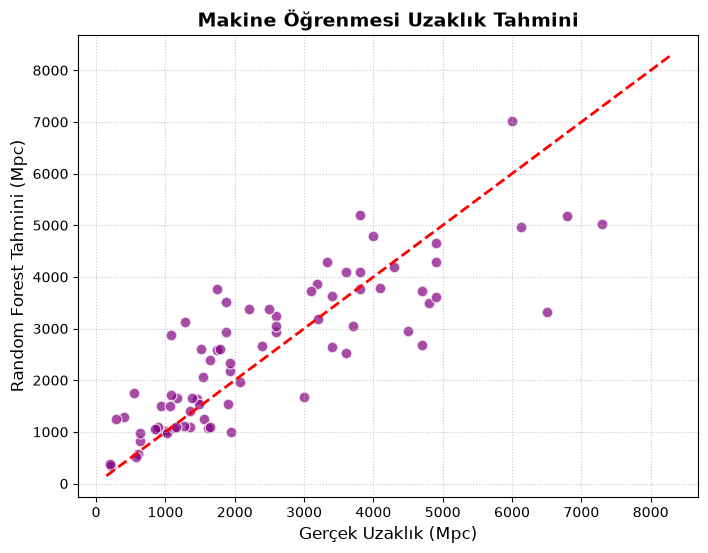

In [17]:
# bu son OLS'ye gore bir random forest ML deniycem

x_ml = df_model[['total_mass_source','inv_snr']]
y_ml = df_model['luminosity_distance']

x_train , x_test , y_train , y_test = train_test_split(x_ml, y_ml , test_size = 0.3 , random_state=42)

rf_model = RandomForestRegressor(n_estimators= 100 , max_depth=5, random_state=42)
rf_model.fit(x_train, y_train)

rf_tahminler = rf_model.predict(x_test)

print(f"Ortalama Sapma (MAE): {mean_absolute_error(y_test, rf_tahminler):.2f} Mpc")
print(f"Başarı Skoru (R2)   : {r2_score(y_test, rf_tahminler):.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_tahminler, color='purple', alpha=0.7, edgecolors='white', s=60)
plt.plot([y_ml.min(), y_ml.max()], [y_ml.min(), y_ml.max()], color='red', linestyle='dashed', lw=2)

plt.xlabel('Gerçek Uzaklık (Mpc)', fontsize=12)
plt.ylabel('Random Forest Tahmini (Mpc)', fontsize=12)
plt.title('Makine Öğrenmesi Uzaklık Tahmini', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


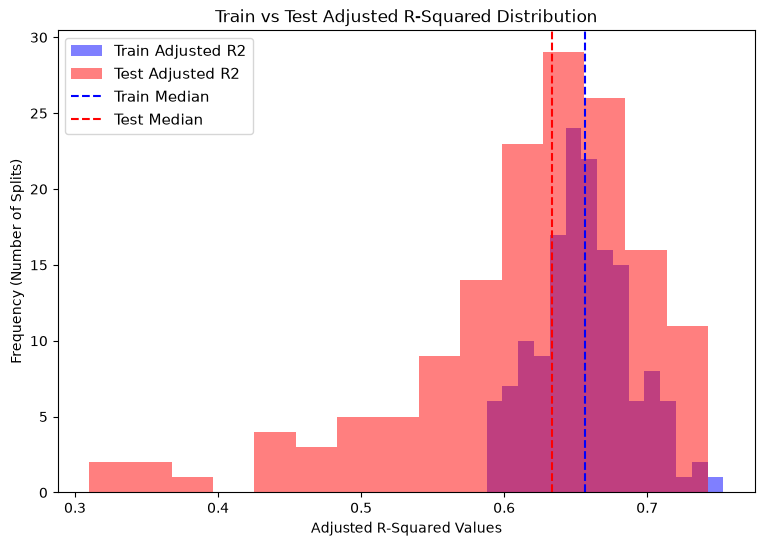

In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score

#repeatedKfold ile deniycem

Y = df_model['luminosity_distance']
X = df_model[['total_mass_source','inv_snr']]

R2_train = []
R2_test = []

rkf = RepeatedKFold(n_splits=3, n_repeats=50, random_state=10)
for train_index, test_index in rkf.split(X):
    X_train = X.iloc[train_index]
    Y_train = Y.iloc[train_index]
    X_test = X.iloc[test_index]
    Y_test = Y.iloc[test_index]

    # Modeli ve fiti olusturma
    X_train = sm.add_constant(X_train)
    model = sm.OLS(Y_train , X_train).fit()
    R2_train.append(model.rsquared_adj)
    
    # Test setinden tahmin
    X_test = sm.add_constant(X_test)
    Y_tahmin = model.predict(X_test)
    # Normal Rkare degeri
    R2score_test = r2_score(Y_test, Y_tahmin)
    # Adjusted Rkare degeri
    n = len(Y_test)
    p = 2           # mass,snr
    R2score_test_adj = 1 - ((1 - R2score_test) * (n - 1) / (n - p - 1))
    R2_test.append(R2score_test_adj)

plt.figure(figsize = (9,6))
plt.hist(R2_train, bins=15, alpha=0.5, color='blue', label='Train Adjusted R2') #edgecolor='white')
plt.hist(R2_test, bins=15, alpha=0.5, color='red', label='Test Adjusted R2') #edgecolor='white')           
median_train = np.median(R2_train)
median_test = np.median(R2_test)
plt.axvline(median_train, color='blue', linestyle='--', label='Train Median')
plt.axvline(median_test, color='red', linestyle='--',label='Test Median')
plt.xlabel('Adjusted R-Squared Values')
plt.ylabel('Frequency (Number of Splits)')
plt.title('Train vs Test Adjusted R-Squared Distribution')
plt.legend(loc='upper left', fontsize=11)
plt.show()



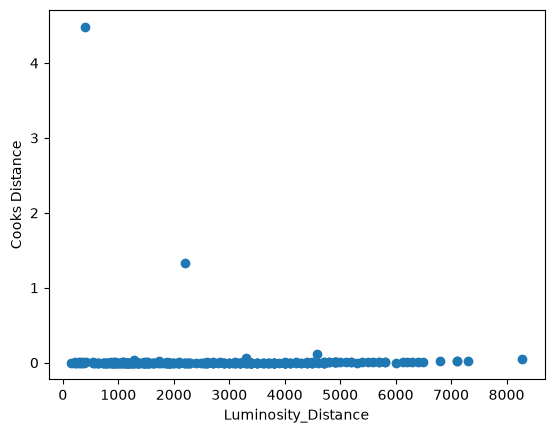

In [34]:
# Cook's distance
# Fitting: LD 

X = df_model[['total_mass_source','network_matched_filter_snr']]
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
np.set_printoptions(suppress=True)

#create instance of influence
influence = model.get_influence()

#obtain Cook's distance for each observation
cooks = influence.cooks_distance

#display Cook's distances
plt.scatter(y, cooks[0])
plt.xlabel('Luminosity_Distance')
plt.ylabel('Cooks Distance')
plt.show()


